<a href="https://colab.research.google.com/github/huanjian/act/blob/main/Action.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Action Recognition**
Action Recognition adalah bidang dalam Computer Vision yang bertujuan untuk mendeteksi, mengenali, dan mengklasifikasikan aktivitas atau gerakan manusia (atau objek) dari data visual seperti video atau rangkaian gambar.



Pengenalan pose tubuh manusia dekade ini berkembang pesat untuk mengetahui makna dari gerakan tubuh yang dilakukan oleh suatu objek. Teknologi yang dapat digunakan adalah Pose Tracking.



Dunia pendidikan saat ini menilai dari hanya dapat menilai siswa dari sisi kognitif saja, namun secara sikap (afektif) masih sangat subjektif tergantung dari sudut pandang pengajar.Penelitian ini diharapkan memiliki kontribusi terhadap pengenalan sikap siswa selama pembelajaran dan memberikan penilaian objektif dari sisi sikap (afektif).



**Penilaian Sikap**
Penilaian sikap yang diusulkan adalah pengenalan siswa selama pembelajaran antara lain **active**, **distract**, dan **sleep**.

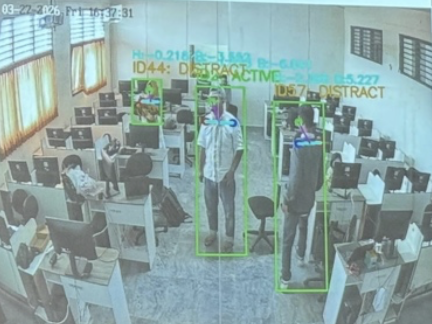


Fitur
ada 3 fitur utama yang akan diproses yaitu:
1. sudut wajah terhadap kamera
2. sudut kedua bahu 90 derajad terhadap kamera
3. dan derajat posisi duduk siswa terhadap kamera

1. Load Library

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

2. Load Pandas Data

In [ ]:
df = pd.read_csv("dataset_camera_siswa.csv")

3. Cek Data

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   No      2000 non-null   int64 
 1   Wajah   2000 non-null   int64 
 2   Bahu    2000 non-null   int64 
 3   Duduk   2000 non-null   int64 
 4   Kelas   2000 non-null   object
dtypes: int64(4), object(1)
memory usage: 78.3+ KB


In [ ]:
df.head()

,No,Wajah,Bahu,Duduk,Kelas
0,1,28,81,52,Sleep
1,2,50,59,61,Sleep
2,3,55,20,27,Sleep
3,4,3,51,37,Distract
4,5,78,86,65,Sleep


In [ ]:
df.tail()


,No,Wajah,Bahu,Duduk,Kelas
1995,1996,43,41,75,Sleep
1996,1997,48,70,20,Distract
1997,1998,7,57,75,Sleep
1998,1999,53,12,46,Sleep
1999,2000,61,90,67,Sleep


4. Statistik Deskriptif

In [ ]:
df.describe()


,No,Wajah,Bahu,Duduk
count,2000.000000,2000.000000,2000.000000,2000.000000
mean,1000.500000,44.813500,45.267000,44.902000
std,577.494589,26.134637,26.627866,26.311187
min,1.000000,0.000000,0.000000,0.000000
25%,500.750000,22.000000,22.000000,22.000000
50%,1000.500000,45.000000,46.000000,44.000000
75%,1500.250000,68.000000,69.000000,68.000000
max,2000.000000,90.000000,90.000000,90.000000


5. Cek Distribusi Kelas


In [ ]:
df['Kelas'].value_counts()

,count
Kelas,
Sleep,1794
Distract,186
Active,20


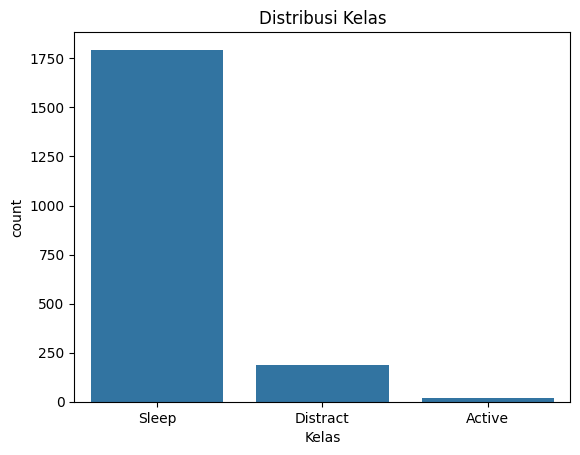

In [ ]:
sns.countplot(x='Kelas', data=df)
plt.title("Distribusi Kelas")
plt.show()

6. Distribusi Fitur Masing-Masing

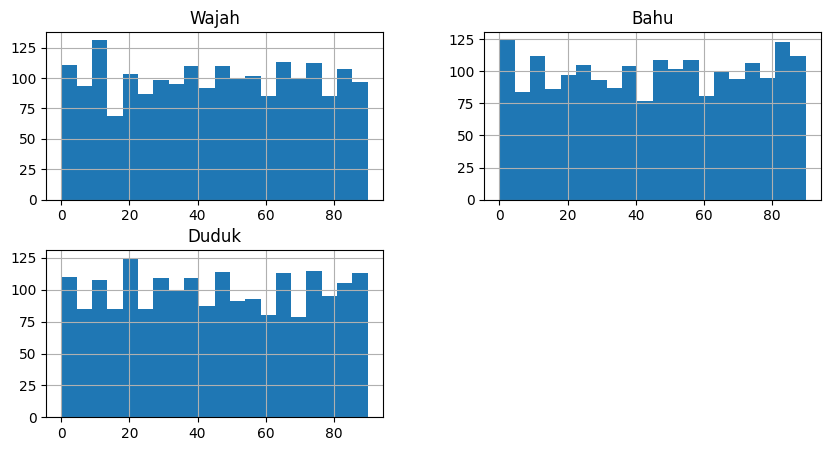

In [ ]:
df[['Wajah','Bahu','Duduk']].hist(bins=20, figsize=(10,5))
plt.show()

7. Boxplot Masing-Masing Fitur

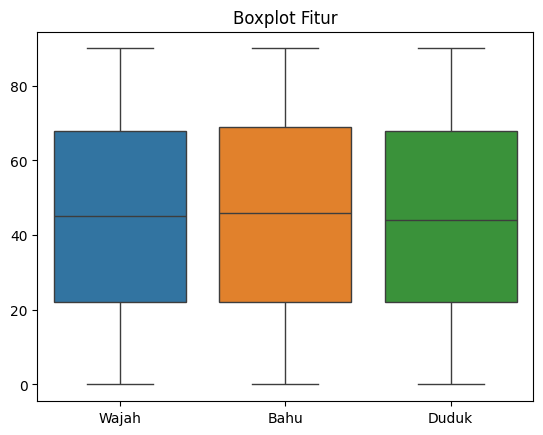

In [ ]:
sns.boxplot(data=df[['Wajah','Bahu','Duduk']])
plt.title("Boxplot Fitur")
plt.show()

8. Korelasi Anter Fitur

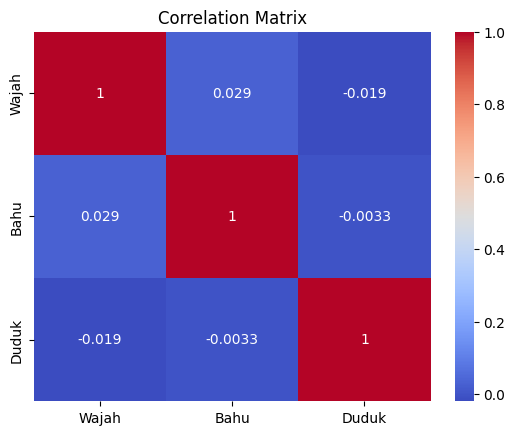

In [ ]:
corr = df[['Wajah','Bahu','Duduk']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

9. Visualisasi Per Kelas

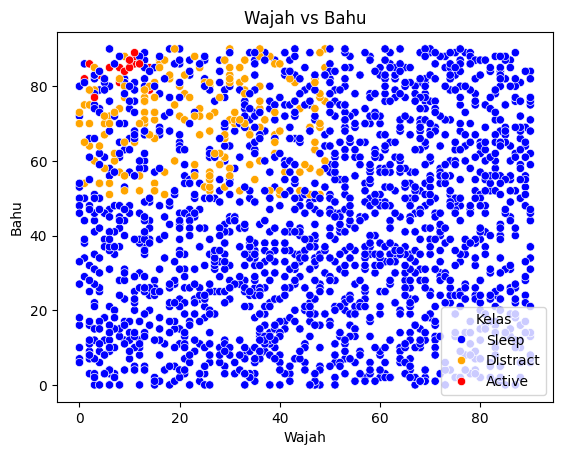

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(
    data=df,
    x='Wajah',
    y='Bahu',
    hue='Kelas',
    palette={
        'Active': 'red',
        'Distract': 'orange',
        'Sleep': 'blue'
    }
)

plt.title("Wajah vs Bahu")
plt.show()

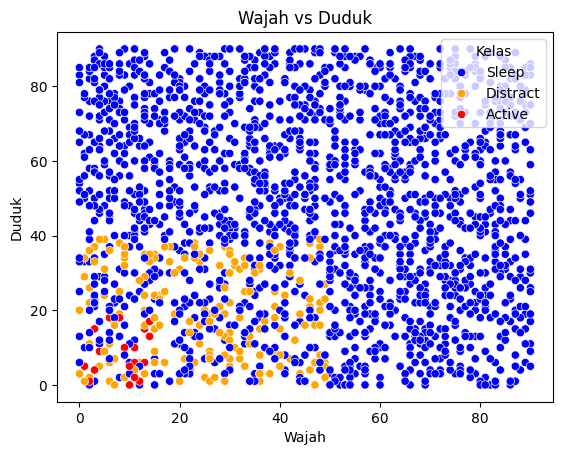

In [ ]:
sns.scatterplot(
    data=df,
    x='Wajah',
    y='Duduk',
    hue='Kelas',
    palette={
        'Active': 'red',
        'Distract': 'orange',
        'Sleep': 'blue'
    }
)

plt.title("Wajah vs Duduk")
plt.show()


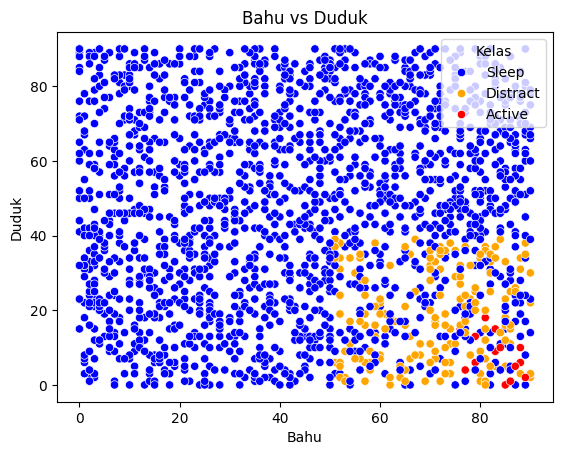

In [ ]:
sns.scatterplot(
    data=df,
    x='Bahu',
    y='Duduk',
    hue='Kelas',
    palette={
        'Active': 'red',
        'Distract': 'orange',
        'Sleep': 'blue'
    }
)

plt.title("Bahu vs Duduk")
plt.show()

10. Visualisasi 3 Dimensi

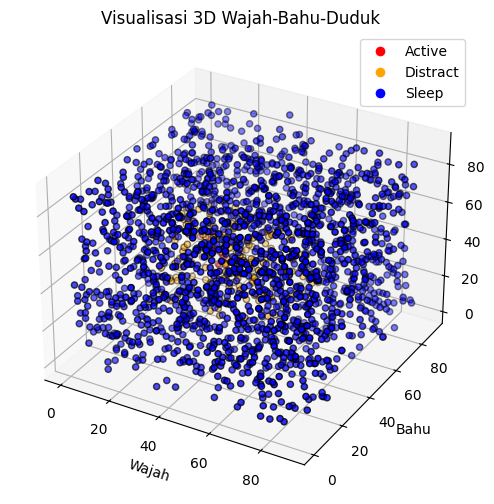

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

color_map = {
    'Active': 'red',
    'Distract': 'orange',
    'Sleep': 'blue'
}

colors = df['Kelas'].map(color_map)

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

from matplotlib.lines import Line2D

legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Active', markerfacecolor='red', markersize=8),
    Line2D([0], [0], marker='o', color='w', label='Distract', markerfacecolor='orange', markersize=8),
    Line2D([0], [0], marker='o', color='w', label='Sleep', markerfacecolor='blue', markersize=8)
]

ax.legend(handles=legend_elements)

ax.scatter(
    df['Wajah'],
    df['Bahu'],
    df['Duduk'],
    c=colors,
    edgecolor='black'
)

ax.set_xlabel('Wajah')
ax.set_ylabel('Bahu')
ax.set_zlabel('Duduk')
ax.set_title('Visualisasi 3D Wajah-Bahu-Duduk')

plt.show()


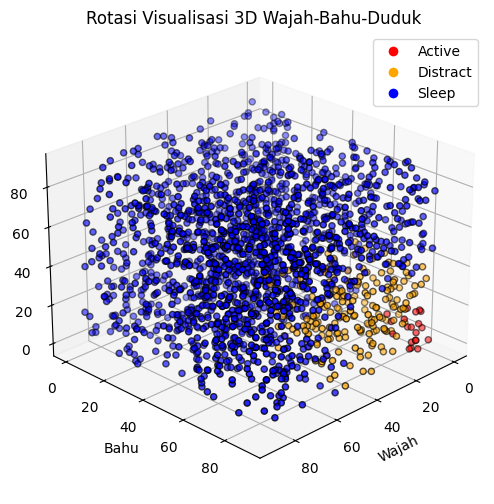

In [ ]:
color_map = {
    'Active': 'red',
    'Distract': 'orange',
    'Sleep': 'blue'
}

colors = df['Kelas'].map(color_map)

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

ax.view_init(elev=25, azim=45)

legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Active', markerfacecolor='red', markersize=8),
    Line2D([0], [0], marker='o', color='w', label='Distract', markerfacecolor='orange', markersize=8),
    Line2D([0], [0], marker='o', color='w', label='Sleep', markerfacecolor='blue', markersize=8)
]

ax.legend(handles=legend_elements)

ax.scatter(
    df['Wajah'],
    df['Bahu'],
    df['Duduk'],
    c=colors,
    edgecolor='black'
)

ax.set_xlabel('Wajah')
ax.set_ylabel('Bahu')
ax.set_zlabel('Duduk')
ax.set_title('Rotasi Visualisasi 3D Wajah-Bahu-Duduk')

plt.show()